In [8]:
import os
os.chdir(r'C:\Users\PC\MarketPulse360')
print(os.getcwd())

C:\Users\PC\MarketPulse360


In [9]:
# ============================================
# CELLULE 1 — Imports & connexion
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

# Style
plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']
print("✅ Connexion OK")

✅ Connexion OK


In [10]:
# ============================================
# CELLULE 2 — Charger les données
# ============================================
df = pd.read_sql("SELECT * FROM fact_orders", engine)
df_products = pd.read_sql("SELECT * FROM dim_products", engine)
df_customers = pd.read_sql("SELECT * FROM dim_customers", engine)

df = df.merge(df_products, on='product_id', how='left')
df = df.merge(df_customers, on='customer_id', how='left')

print(f"Shape: {df.shape}")
print(f"Période: {df['order_date'].min()} → {df['order_date'].max()}")
df.head()

Shape: (110840, 22)
Période: 2016-09-15 → 2018-08-29


,order_id,customer_id,product_id,seller_id,order_date,year,month,day_of_week,product_price,freight_value,...,order_status,review_score,category,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_city,customer_state
0,001ac194d4a326a6fa99b581e9a3d963,f4f17ada91ef010cbde3892ae54e625f,dbaee28f4ee64465838a229582d77520,ffc470761de7d0232558ba5e786e57b7,2018-07-04,2018,7,3,54.00,8.54,...,delivered,5.0,construction_tools_construction,418.0,19.0,6.0,13.0,3d01f9412759a6a68f249b76eca0de78,cubatao,SP
1,001b76dd48a5b1eee3e87778daa40df8,a62843b08086d1629415a203a7fd419d,dbb67791e405873b259e4656bf971246,9c0e69c7bf2619675bbadf47b43f655a,2018-03-26,2018,3,1,81.99,13.01,...,delivered,5.0,computers_accessories,207.0,17.0,12.0,13.0,b32ff8caad5902c55fa167e7dc77cc69,santa salete,SP
2,001c85b5f68d2be0cb0797afc9e8ce9a,48ed31e735f1c420ed6ca3637b7c744d,84f456958365164420cfc80fbe4c7fab,4a3ca9315b744ce9f8e9374361493884,2017-11-24,2017,11,5,99.00,13.71,...,delivered,2.0,bed_bath_table,1550.0,44.0,14.0,34.0,55a269f324455e78349e7b9b7e7e5911,sao paulo,SP
3,001d8f0e34a38c37f7dba2a37d4eba8b,d987da9fb4086ab7c2c0f83963cd6722,e67307ff0f15ade43fcb6e670be7a74c,f4aba7c0bca51484c30ab7bdc34bcdd1,2017-05-14,2017,5,0,18.99,7.78,...,delivered,1.0,health_beauty,150.0,43.0,13.0,14.0,870a0bdc769f9a7870309036740e79ea,sao paulo,SP
4,001d8f0e34a38c37f7dba2a37d4eba8b,d987da9fb4086ab7c2c0f83963cd6722,e67307ff0f15ade43fcb6e670be7a74c,f4aba7c0bca51484c30ab7bdc34bcdd1,2017-05-14,2017,5,0,18.99,7.78,...,delivered,1.0,health_beauty,150.0,43.0,13.0,14.0,870a0bdc769f9a7870309036740e79ea,sao paulo,SP


C:\Users\PC\AppData\Local\Temp\ipykernel_6132\2308300204.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(monthly['period'], rotation=45, ha='right')


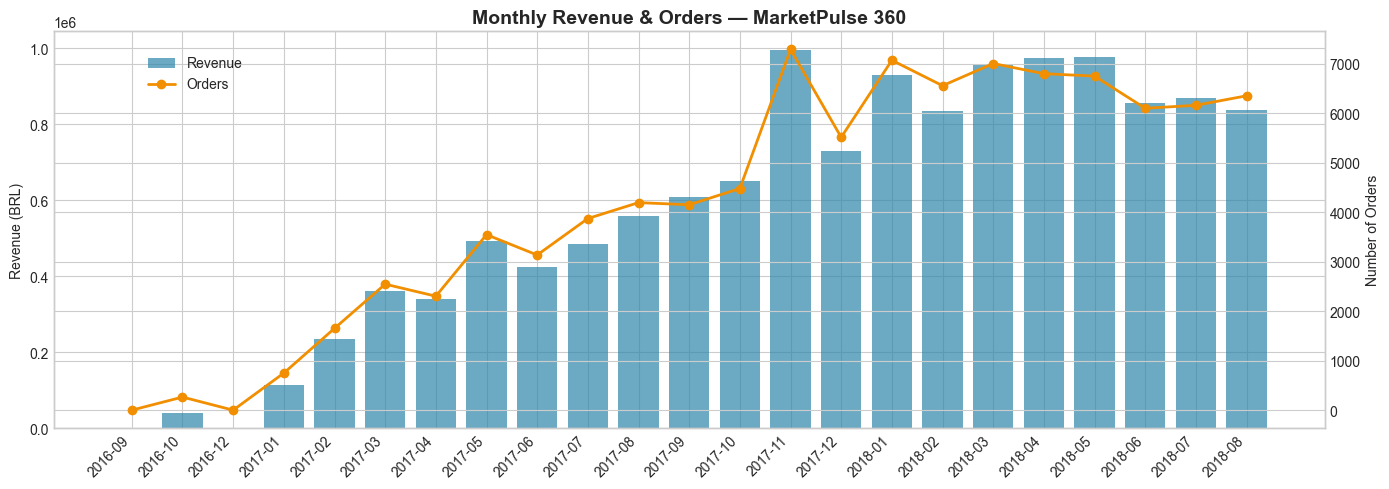

In [11]:
# ============================================
# CELLULE 3 — Revenu mensuel
# ============================================
monthly = df.groupby(['year', 'month']).agg(
    revenue=('product_price', 'sum'),
    nb_orders=('order_id', 'nunique')
).reset_index()
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.bar(monthly['period'], monthly['revenue'], color=colors[0], alpha=0.7, label='Revenue')
ax2.plot(monthly['period'], monthly['nb_orders'], color=colors[2], marker='o', linewidth=2, label='Orders')
ax1.set_xticklabels(monthly['period'], rotation=45, ha='right')
ax1.set_ylabel('Revenue (BRL)')
ax2.set_ylabel('Number of Orders')
plt.title('Monthly Revenue & Orders — MarketPulse 360', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig('reports/monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

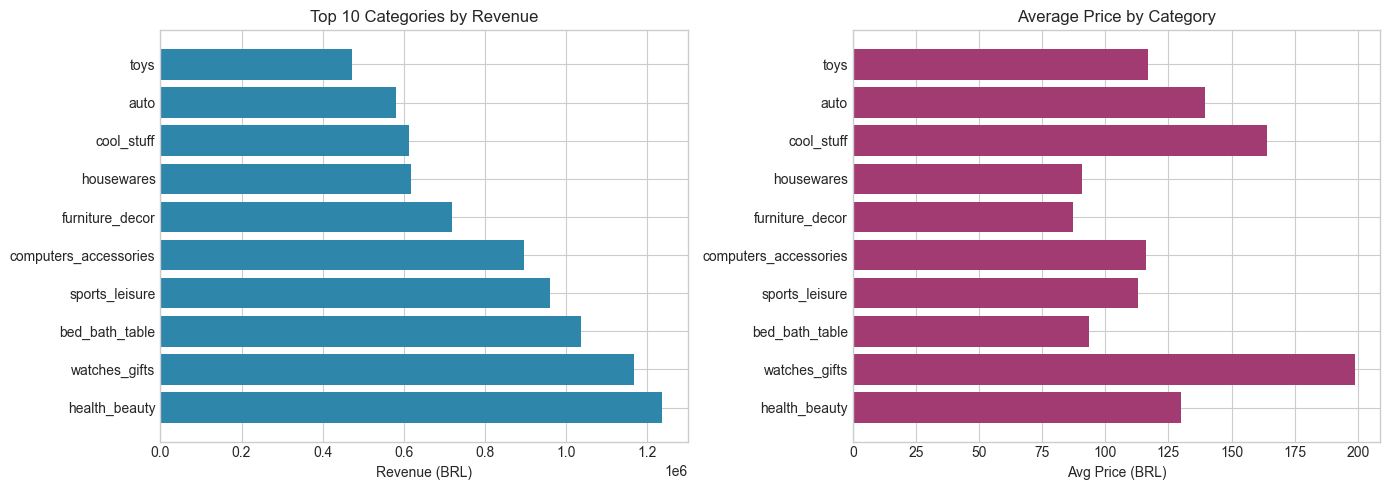

In [12]:
# ============================================
# CELLULE 4 — Top catégories
# ============================================
top_cat = df.groupby('category').agg(
    revenue=('product_price', 'sum'),
    nb_orders=('order_id', 'nunique'),
    avg_price=('product_price', 'mean')
).sort_values('revenue', ascending=False).head(10).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top_cat['category'], top_cat['revenue'], color=colors[0])
axes[0].set_title('Top 10 Categories by Revenue')
axes[0].set_xlabel('Revenue (BRL)')
axes[1].barh(top_cat['category'], top_cat['avg_price'], color=colors[1])
axes[1].set_title('Average Price by Category')
axes[1].set_xlabel('Avg Price (BRL)')
plt.tight_layout()
plt.savefig('reports/top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ============================================
# CELLULE 5 — Export KPIs CSV pour Power BI
# ============================================
monthly.to_csv('data/processed/kpi_monthly_revenue.csv', index=False)
top_cat.to_csv('data/processed/kpi_top_categories.csv', index=False)
print("✅ KPIs exportés dans data/processed/")

✅ KPIs exportés dans data/processed/
